In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Replace Cufflinks config with Plotly default settings (optional)
import plotly.io as pio
pio.templates.default = "plotly_white"

# reading the csv file
df_population_raw = pd.read_csv('population_total.csv')
# dropping null values
df_population_raw.dropna(inplace=True)
# making a pivot table
df_pivot = df_population_raw.pivot(index='year', columns='country', values='population')
# selecting some countries
df_pivot = df_pivot[['United States', 'India', 'China', 'Indonesia', 'Brazil']]
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


# 1 Lineplot

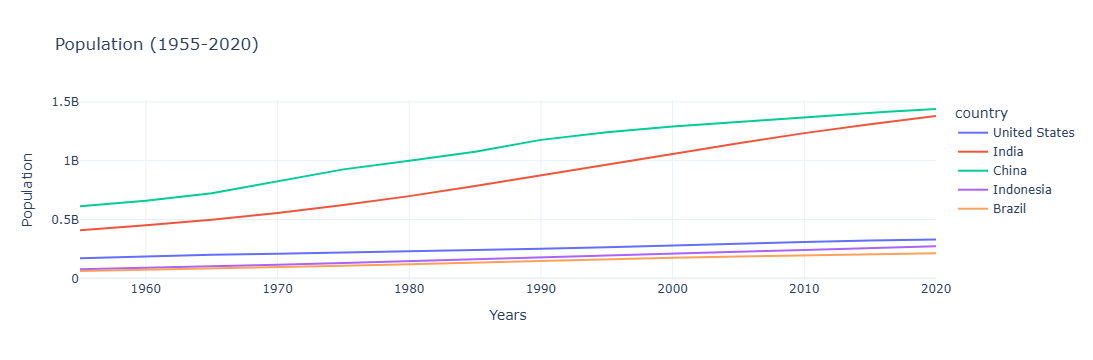

In [2]:
fig = px.line(df_pivot, x=df_pivot.index, y=df_pivot.columns,
              title='Population (1955-2020)',
              labels={'value': 'Population', 'year': 'Years', 'variable': 'Country'})
fig.show()

# 2 Barplot (2020)

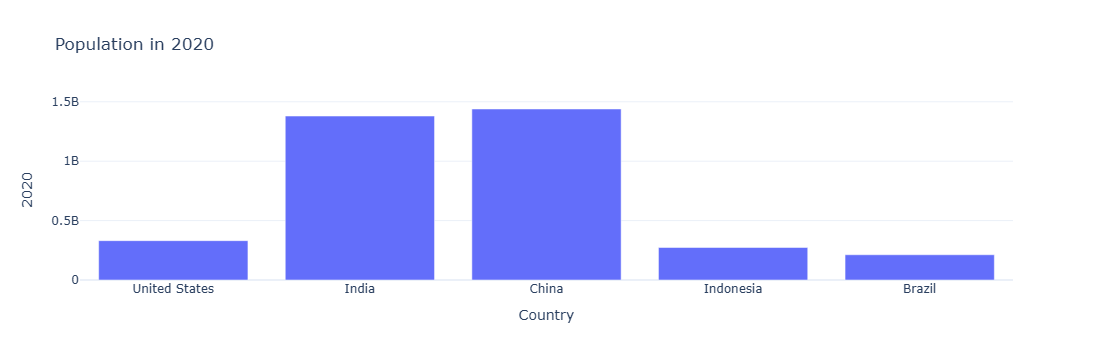

In [3]:
# selecting only one year (2020)
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])].T

fig = px.bar(df_pivot_2020, x=df_pivot_2020.index, y=2020,
             title='Population in 2020',
             labels={2020: 'Population', 'country': 'Country'})
fig.show()

# 3 Grouped Barplot (Multiple Years)

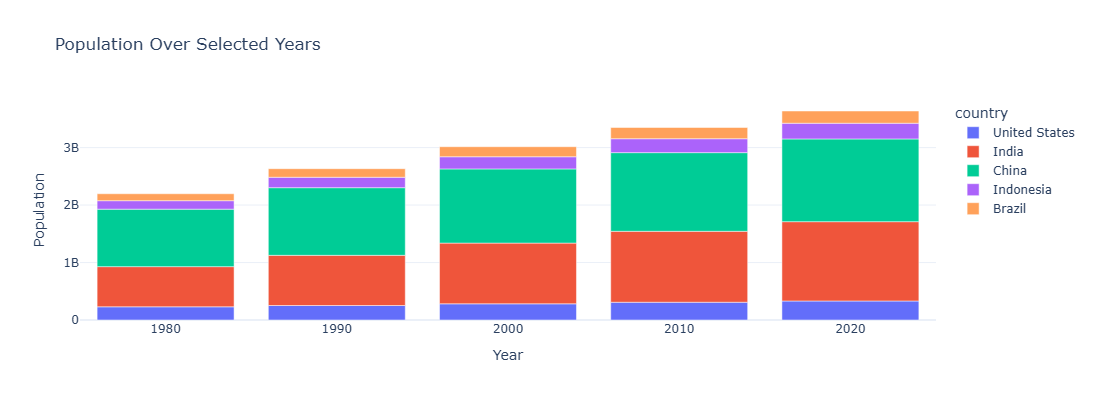

In [4]:
# selecting a few years
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]

# Method 1: Direct approach (most common)
fig = px.bar(df_pivot_sample, 
             x=df_pivot_sample.index, 
             y=df_pivot_sample.columns,
             title='Population Over Selected Years',
             labels={'value': 'Population', 'year': 'Year', 'variable': 'Country'})

# ADD THIS LINE for figsize=(8,4):
fig.update_layout(width=800, height=400)

fig.show()

# 4 Piechart (2020)

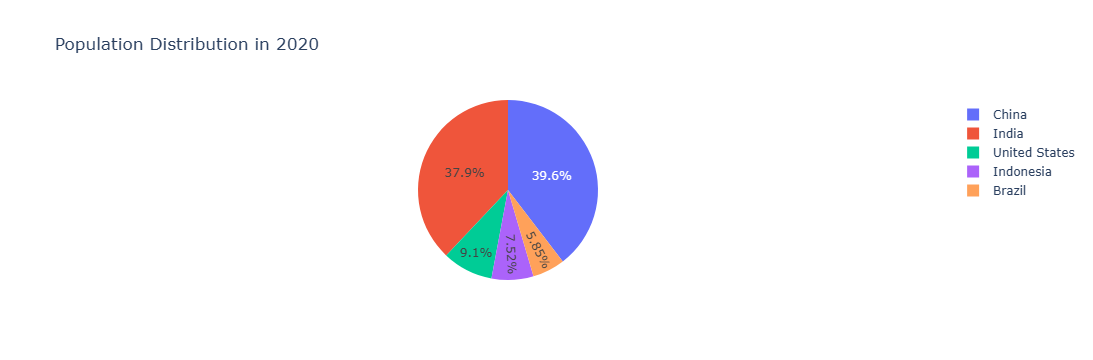

In [5]:
df_pivot_2020 = df_pivot_2020.reset_index()
df_pivot_2020 = df_pivot_2020.rename(columns={2020: '2020'})

fig = px.pie(df_pivot_2020, values='2020', names='country',
             title='Population Distribution in 2020')
fig.show()

# 5 Boxplot
Single Country

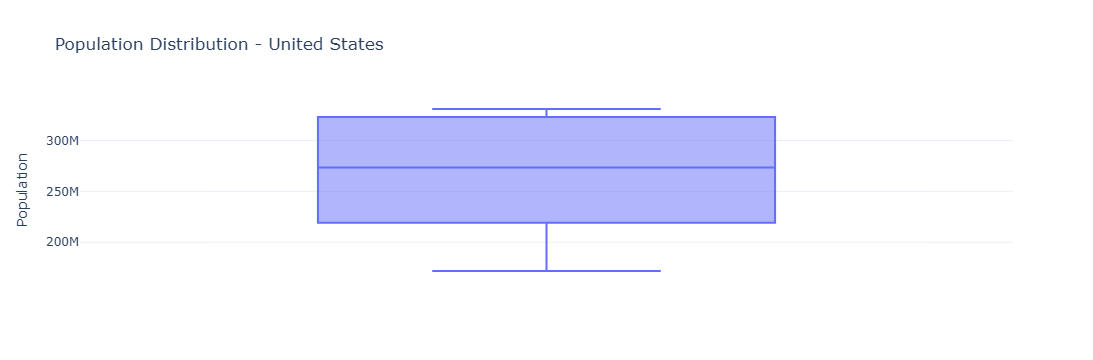

In [6]:
fig = px.box(df_pivot, y='United States', title='Population Distribution - United States',
             labels={'United States': 'Population'})
fig.show()

# 6 All Countries

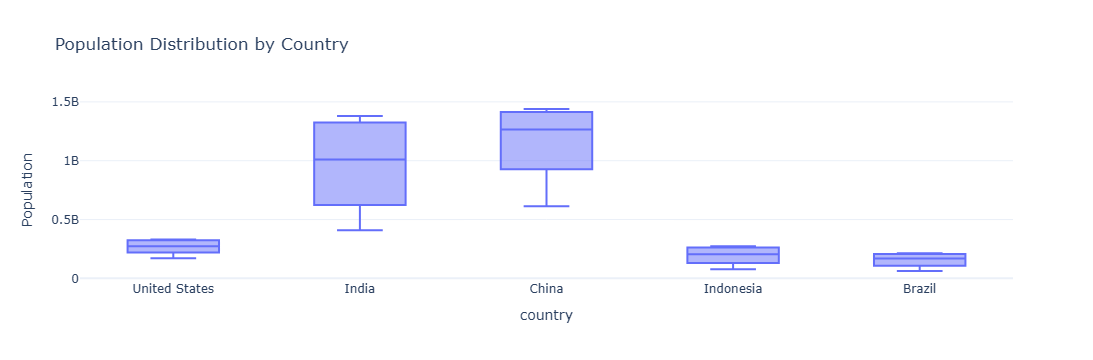

In [7]:
fig = px.box(df_pivot, title='Population Distribution by Country',
             labels={'value': 'Population', 'variable': 'Country'})
fig.show()

# 7 Histogram

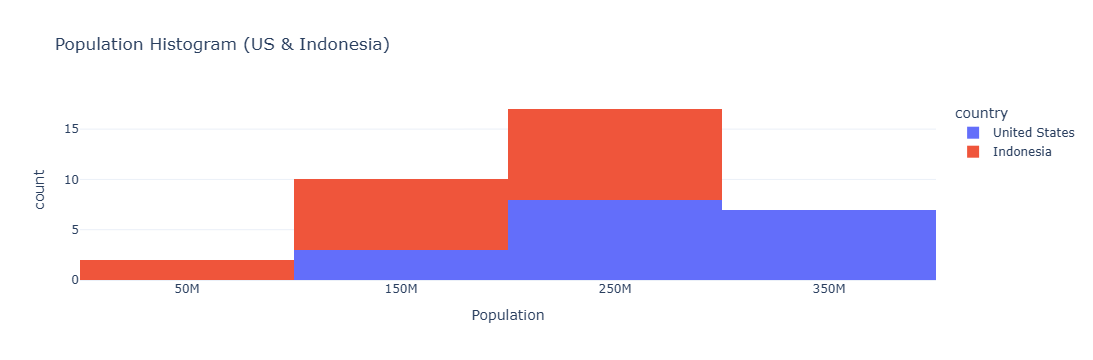

In [8]:
fig = px.histogram(df_pivot[['United States', 'Indonesia']], 
                   nbins=3,
                   labels={'value': 'Population', 'variable': 'Country'},
                   title='Population Histogram (US & Indonesia)')
fig.show()

# 8 Scatter Plot

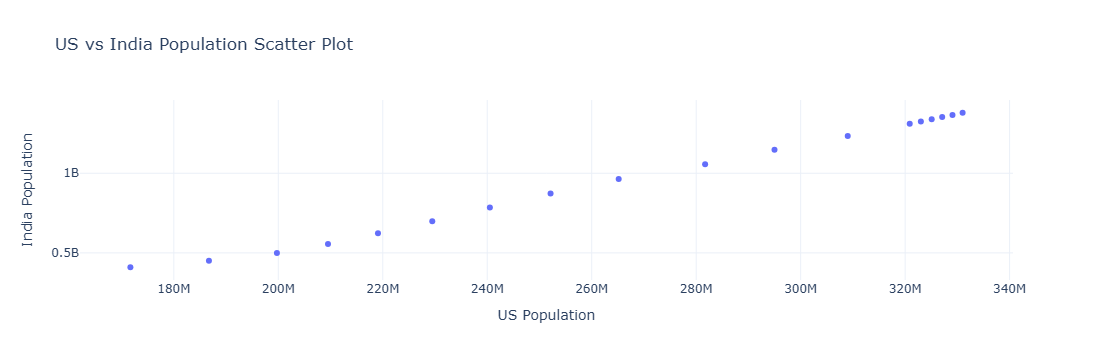

In [9]:
fig = px.scatter(df_pivot, x='United States', y='India',
                 title='US vs India Population Scatter Plot',
                 labels={'United States': 'US Population', 'India': 'India Population'})
fig.show()